# quantem.data — browse, download, and view shared datasets
Pull and publish reference 4D-STEM / HAADF datasets with one line, no `huggingface_hub` code. The repo is **public**: browsing and downloading need **no token**; only uploading does.

> `quantem.data` just moves bytes (standalone). Loading + `Show2D` below come from `quantem.widget`, which depends on `quantem.data` — so installing the widget gets you both.

## Install
```bash
pip install -i https://test.pypi.org/simple/ --extra-index-url https://pypi.org/simple/ quantem.widget
```
(`--extra-index-url` because quantem.widget/.data are on TestPyPI for now.)

## 1. See what's shared — structure
`tree()` groups datasets by type with sizes; no Hugging Face visit needed.

In [1]:
from quantem.data import tree, browse, read_meta, load
tree()

bobleesj/quantem-data  (30.9 GB total, 11 datasets)

4dstem/   (7 datasets, 30.80 GB)
     3157.9 MB  gold_30mrad1.3mx04
     7081.7 MB  gold_30mrad1.3mx06
     7120.0 MB  gold_30mrad1.3mx07
     7045.0 MB  gold_30mrad1.3mx09
     4889.1 MB  gold_512
     1208.0 MB  gold_512_npy_bin4
      302.0 MB  gold_512_npy_bin8

haadf/   (4 datasets, 0.08 GB)
        8.7 MB  gold_drift_0deg
        8.7 MB  gold_drift_90deg
       33.8 MB  gold_haadf
       33.6 MB  gold_haadf_npy


## 2. Browse visually — pick before downloading GBs
`browse()` shows a thumbnail per dataset. Thumbnails are tiny (KB); the multi-GB data is never touched.

bobleesj/quantem-data  (30.9 GB total, 11 datasets)

4dstem/   (7 datasets, 30.80 GB)
     3157.9 MB  gold_30mrad1.3mx04
     7081.7 MB  gold_30mrad1.3mx06
     7120.0 MB  gold_30mrad1.3mx07
     7045.0 MB  gold_30mrad1.3mx09
     4889.1 MB  gold_512
     1208.0 MB  gold_512_npy_bin4
      302.0 MB  gold_512_npy_bin8

haadf/   (4 datasets, 0.08 GB)
        8.7 MB  gold_drift_0deg
        8.7 MB  gold_drift_90deg
       33.8 MB  gold_haadf
       33.6 MB  gold_haadf_npy


bobleesj/quantem-data — 30.9 GB, 11 datasets 4dstem/ (7) gold_30mrad1.3mx04 4dstem · 3.16 GB download("gold_30mrad1.3mx04") gold_30mrad1.3mx06 4dstem · 7.08 GB download("gold_30mrad1.3mx06") gold_30mrad1.3mx07 4dstem · 7.12 GB download("gold_30mrad1.3mx07") gold_30mrad1.3mx09 4dstem · 7.05 GB download("gold_30mrad1.3mx09") gold_512 4dstem · 4.89 GB download("gold_512") gold_512_npy_bin4 4dstem · 1.21 GB download("gold_512_npy_bin4") gold_512_npy_bin8 4dstem · 0.30 GB download("gold_512_npy_bin8") haadf/ (4) gold_drift_0deg haadf · 0.01 GB download("gold_drift_0deg") gold_drift_90deg haadf · 0.01 GB download("gold_drift_90deg") gold_haadf haadf · 0.03 GB download("gold_haadf") gold_haadf_npy haadf · 0.03 GB download("gold_haadf_npy")
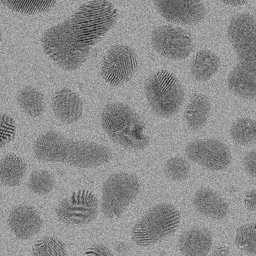
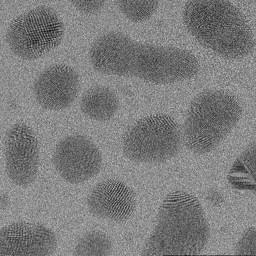
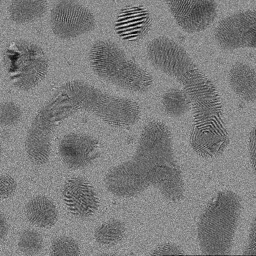
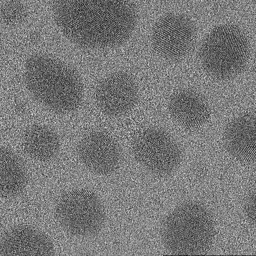
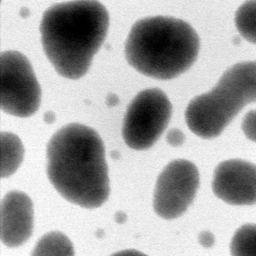
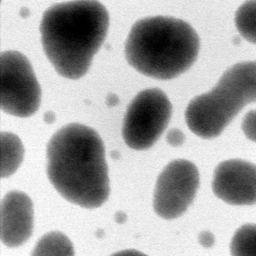
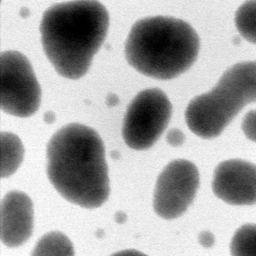
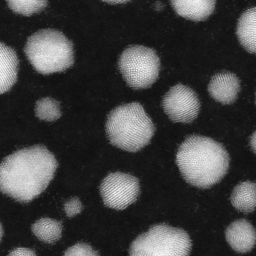
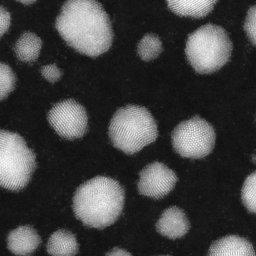
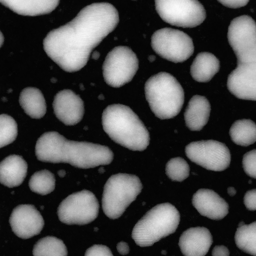
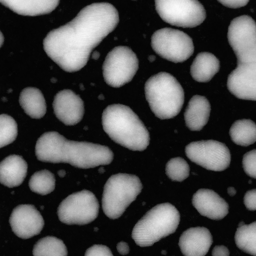

In [2]:
browse()

## 3. Check a dataset's calibration
`read_meta` returns the scan sampling / shape / units sidecar, or `None`.

In [3]:
read_meta('gold_512_npy_bin4')

{'name': 'gold_512_npy_bin4',
 'shape': [512, 512, 48, 48],
 'dtype': 'uint16',
 'sampling': [0.5, 0.5, 1.84, 1.84],
 'units': ['A', 'A', 'mrad', 'mrad'],
 'bin_factor': {'scan': 1, 'det': 4},
 'original_shape': [512, 512, 192, 192],
 'original_sampling': [0.5, 0.5, 0.46, 0.46],
 'source': 'Arina 4D-STEM master /home/owner/ssd/data/bob/20260423_gold_drift_v6_4dstem_pair/gold_004_master.h5 (drift-pair acquisition; sibling session 20260408_gold_4dstem_512_ssb/dataset.yaml supplies optics)',
 'purpose': 'workshop / Colab demo - full real-space, detector-only bin',
 'voltage_kV': 300,
 'camera_length_mm': 91,
 'probe_semiangle_mrad': 30,
 'mag_MX': None,
 'rotation_deg': 0.0,
 'voltage_kV_source': 'confirmed via session HAADF EMD (20260423/0072-*.emd, AccelerationVoltage)',
 'probe_semiangle_source': 'confirmed via session HAADF EMD (BeamConvergence 0.02999 rad)',
 'camera_length_source': 'confirmed via session HAADF EMD (CameraLength 0.091 m)',
 'scan_sampling_A_source': 'operator pattern

## 4. Download and view it - one call
`load(name)` downloads **and** returns the data ready to use: a single image comes back as a `Dataset2d` (pixels on `.array`, `.show()` opens the viewer), a 4D-STEM acquisition comes back loaded. Want just the path? Use `download(name)` instead and load it yourself.

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

'gold_drift_0deg' (0.01 GB) is already cached on disk - no re-download.
  cached at: /home/owner/.cache/huggingface/hub/datasets--bobleesj--quantem-data/snapshots/25e2c3e9e49849d7ecf335fb4994143778bd2e23/haadf/gold_drift_0deg.emd


(2048, 2048) uint16


(<Figure size 400x400 with 1 Axes>,
 <Axes: title={'center': 'gold_drift_0deg'}>)

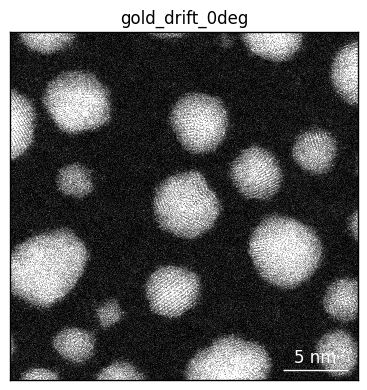

In [4]:
ds = load('gold_drift_0deg')   # ~9 MB HAADF, downloads then loads
print(ds.array.shape, ds.array.dtype)
ds.show()

## Publish a dataset (owner only - needs an HF write token)
`upload` writes, so log in first (`huggingface-cli login` or `HF_TOKEN`). Attach calibration with `meta=`. Not run here (it mutates the repo):
```python
from quantem.data import upload
upload('my_scan.h5', name='gold_run42', folder='4dstem',
       meta={'voltage_kV': 300, 'scan_sampling_A': 0.2})
```
Same from the shell:
```bash
quantem-data list                       # or: tree / status
quantem-data meta gold_512_npy_bin4
quantem-data download gold_drift_0deg
quantem-data upload my_scan.h5 --folder 4dstem --name gold_run42 --meta cal.json
```